In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error


In [3]:
data = pd.read_csv("C:/Users/Durosimi/PROJECTS/Parkinson/data/processed/predictions_temporal.csv")

In [5]:
data.head()

,subject,age,sex,test_time,motor_updrs,total_updrs,jitter,jitter_abs,jitter_rap,jitter_ppq5,...,hnr,rpde,dfa,ppe,motor_updrs_lag1,delta_time,delta_updrs,updrs_rolling_mean_3,updrs_rolling_std_3,pred_motor_updrs
0,1,72,False,5.6438,28.199,34.398,0.00413,0.000021,0.00173,0.00165,...,26.641,0.50911,0.53637,0.251830,28.199,0.0007,0.000,28.199000,0.000000,28.209282
1,1,72,False,5.6451,28.199,34.398,0.00217,0.000011,0.00086,0.00099,...,30.749,0.41216,0.54572,0.094704,28.199,0.0013,0.000,28.199000,0.000000,28.200875
2,1,72,False,5.6458,28.199,34.399,0.00294,0.000015,0.00121,0.00125,...,27.530,0.40986,0.53572,0.166350,28.199,0.0007,0.000,28.199000,0.000000,28.203073
3,1,72,False,5.6458,28.199,34.399,0.00250,0.000013,0.00110,0.00090,...,32.102,0.31053,0.52767,0.065937,28.199,0.0000,0.000,28.199000,0.000000,28.197154
4,1,72,False,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,27.183,0.43493,0.56477,0.108100,28.199,7.0202,0.248,28.281667,0.143183,28.420569


In [9]:
required_cols = [
    "subject", "test_time",
    "motor_updrs", "pred_motor_updrs"
]

for col in required_cols:
    assert col in data.columns, f"Missing column: {col}"


In [11]:
data = data.sort_values(["subject", "test_time"]).reset_index(drop=True)


In [22]:
def plot_patient_progression(subject_id):
    patient = data[data["subject"] == subject_id]

    plt.figure(figsize=(10, 5))
    plt.plot(
        patient["test_time"],
        patient["motor_updrs"],
        marker="o",
        label="Actual"
    )
    plt.plot(
        patient["test_time"],
        patient["pred_motor_updrs"],
        marker="x",
        linestyle="--",
        label="Predicted"
    )

    plt.title(f"Motor UPDRS Progression – Subject {subject_id}")
    plt.xlabel("Time since baseline")
    plt.ylabel("Motor UPDRS")
    plt.legend()
    plt.grid(True)
    plt.show()


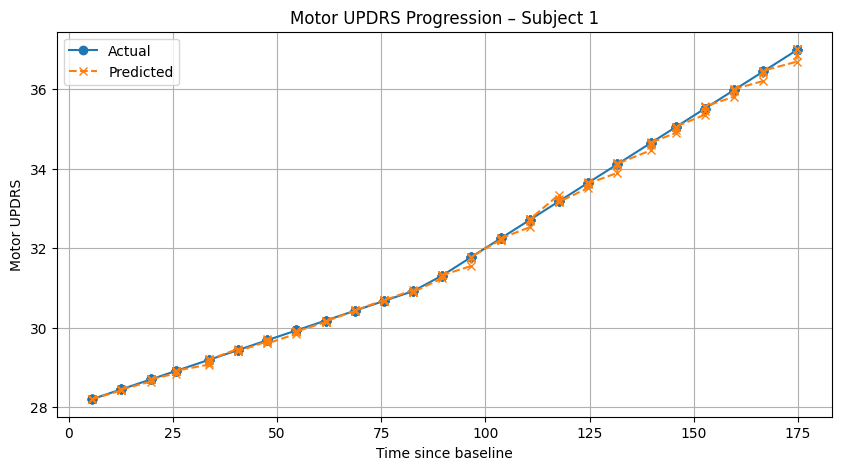

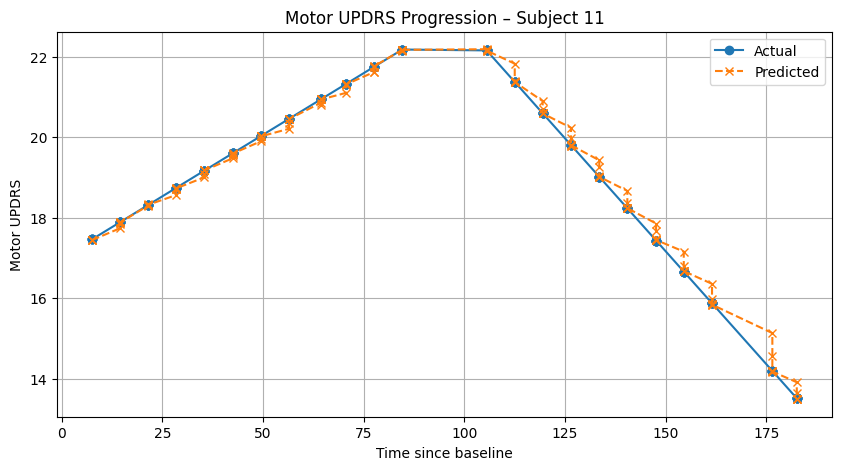

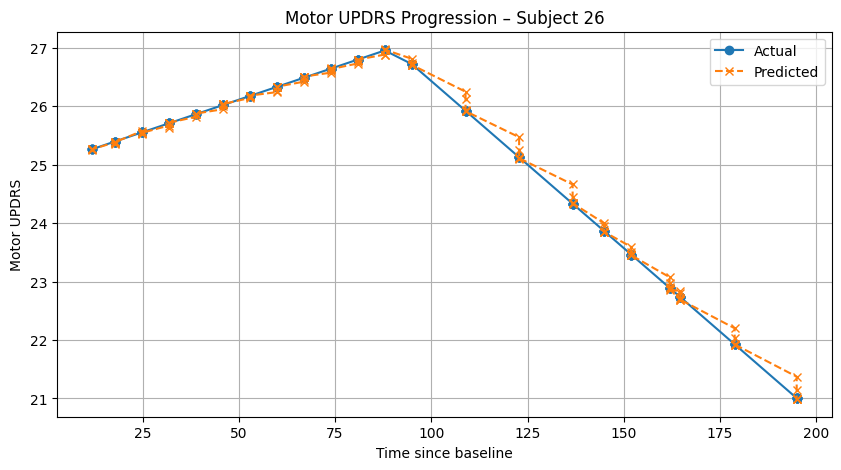

In [24]:
subjects = data["subject"].unique()
plot_patient_progression(subjects[0])
plot_patient_progression(subjects[10])
plot_patient_progression(subjects[25])

In [27]:
trend_results = []

for subject_id in data["subject"].unique():
    patient = data[data["subject"] == subject_id]

    if patient.shape[0] < 3:
        continue

    actual_corr, _ = spearmanr(
        patient["test_time"],
        patient["motor_updrs"]
    )

    pred_corr, _ = spearmanr(
        patient["test_time"],
        patient["pred_motor_updrs"]
    )

    trend_results.append({
        "subject": subject_id,
        "actual_trend": actual_corr,
        "predicted_trend": pred_corr
    })

trend_df = pd.DataFrame(trend_results)
trend_df.head()


,subject,actual_trend,predicted_trend
0,1,0.999531,0.998820
1,2,0.999605,0.999222
2,3,0.749441,0.752367
3,4,0.999615,0.999189
4,5,0.901758,0.819896


In [29]:
trend_df[["actual_trend", "predicted_trend"]].describe()


,actual_trend,predicted_trend
count,42.000000,42.000000
mean,0.290648,0.287211
std,0.706329,0.693469
min,-0.999493,-0.998983
25%,-0.324964,-0.311049
50%,0.504290,0.502450
75%,0.988049,0.979937
max,0.999737,0.999238


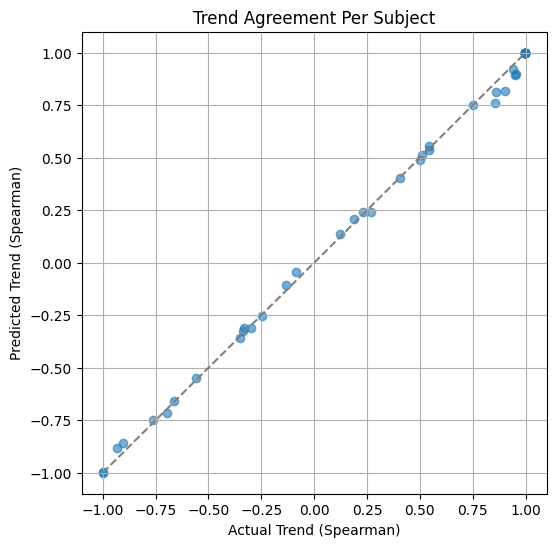

In [32]:
plt.figure(figsize=(6, 6))
plt.scatter(
    trend_df["actual_trend"],
    trend_df["predicted_trend"],
    alpha=0.6
)
plt.plot([-1, 1], [-1, 1], "--", color="gray")
plt.xlabel("Actual Trend (Spearman)")
plt.ylabel("Predicted Trend (Spearman)")
plt.title("Trend Agreement Per Subject")
plt.grid(True)
plt.show()


In [35]:
trend_df["actual_direction"] = np.sign(trend_df["actual_trend"])
trend_df["predicted_direction"] = np.sign(trend_df["predicted_trend"])

direction_accuracy = (
    trend_df["actual_direction"]
    == trend_df["predicted_direction"]
).mean()

direction_accuracy


1.0

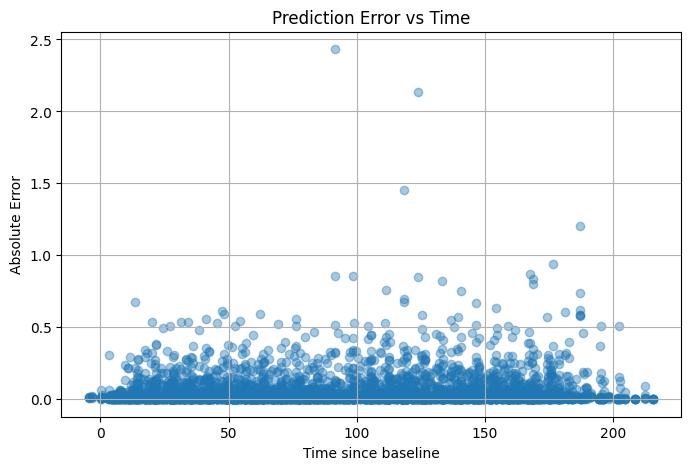

In [42]:
data["abs_error"] = np.abs(
    data["motor_updrs"] - data["pred_motor_updrs"]
)

plt.figure(figsize=(8, 5))
plt.scatter(
    data["test_time"],
    data["abs_error"],
    alpha=0.4
)
plt.xlabel("Time since baseline")
plt.ylabel("Absolute Error")
plt.title("Prediction Error vs Time")
plt.grid(True)
plt.show()

In [44]:
feature_cols_no_lag = [
    "jitter", "shimmer", "hnr",
    "dfa", "rpde", "ppe",
    "age", "sex",
    "delta_time"
]

X_no_lag = data[feature_cols_no_lag]


In [46]:
X_no_lag.head()

,jitter,shimmer,hnr,dfa,rpde,ppe,age,sex,delta_time
0,0.00413,0.01282,26.641,0.53637,0.50911,0.251830,72,False,0.0007
1,0.00217,0.00798,30.749,0.54572,0.41216,0.094704,72,False,0.0013
2,0.00294,0.01058,27.530,0.53572,0.40986,0.166350,72,False,0.0007
3,0.00250,0.00631,32.102,0.52767,0.31053,0.065937,72,False,0.0000
4,0.00300,0.02024,27.183,0.56477,0.43493,0.108100,72,False,7.0202
